# Model Training

## 1.1 Import Data and Required Packages

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 #Modeling
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

### import the csv file as pandas data frame

In [23]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### preparing X and Y variables

In [24]:
X = df.drop(columns=['math score'],axis=1)

In [25]:
print("Categories in 'gender' variable:  ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:  ",end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:  ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:  ",end=" ")
print(df['test preparation course'].unique())


Categories in 'gender' variable:   ['female' 'male']
Categories in 'race/ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:   ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:   ['standard' 'free/reduced']
Categories in 'test preparation course' variable:   ['none' 'completed']


In [26]:
y=df['math score']

In [27]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [28]:
# Create column Transformer with 3 type of transformers
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

## 1.2 Read Dataset

In [29]:
df = pd.read_csv("data/stud.csv")

df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


## 1.3 Separate Input and Output Features

In [30]:
X = df.drop(columns=["math score"], axis=1)
y = df["math score"]

## 1.4 Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 1.5 Data Preprocessing

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [33]:
X=preprocessor.fit_transform(X)

In [34]:
X.shape

(1000, 19)

In [35]:
# separate dataset into jtrain and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [38]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, mse, r2_square

In [40]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluation
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    # Store model name
    model_list.append(name)

    # Print results
    print(f"Model: {name}")

    print("Model performance on training set")
    print(f"- RMSE: {model_train_rmse:.4f}")
    print(f"- MAE: {model_train_mae:.4f}")
    print(f"- R2 Score: {model_train_r2:.4f}")
    print("_________________________________")

    print("Model performance on test set")
    print(f"- RMSE: {model_test_rmse:.4f}")
    print(f"- MAE: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")

    r2_list.append(model_test_r2)

    print("=" * 35)
    print("\n")

Model: Linear Regression
Model performance on training set
- RMSE: 28.3349
- MAE: 4.2667
- R2 Score: 0.8743
_________________________________
Model performance on test set
- RMSE: 29.0952
- MAE: 4.2148
- R2 Score: 0.8804


Model: Ridge
Model performance on training set
- RMSE: 28.3378
- MAE: 4.2650
- R2 Score: 0.8743
_________________________________
Model performance on test set
- RMSE: 29.0563
- MAE: 4.2111
- R2 Score: 0.8806


Model: Lasso
Model performance on training set
- RMSE: 43.4783
- MAE: 5.2063
- R2 Score: 0.8071
_________________________________
Model performance on test set
- RMSE: 42.5063
- MAE: 5.1579
- R2 Score: 0.8253


Model: K-Neighbors Regressor
Model performance on training set
- RMSE: 32.6465
- MAE: 4.5190
- R2 Score: 0.8552
_________________________________
Model performance on test set
- RMSE: 52.6610
- MAE: 5.6310
- R2 Score: 0.7836


Model: Decision Tree Regressor
Model performance on training set
- RMSE: 0.0781
- MAE: 0.0187
- R2 Score: 0.9997
_______________

### Results

In [41]:
pd.DataFrame({"Model": model_list, "R2 Score": r2_list}).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
1,Ridge,0.880593
0,Linear Regression,0.880433
7,AdaBoost Regressor,0.853871
6,CatBoost Regressor,0.851632
2,Lasso,0.825320
5,XGBoost Regressor,0.821221
3,K-Neighbors Regressor,0.783589
4,Decision Tree Regressor,0.763005


## Linear Regression

In [42]:
line_model = LinearRegression()
line_model=line_model.fit(X_train, y_train)
y_pred = line_model.predict(X_test)
score=r2_score(y_test, y_pred)
score

0.8804332983749565

## plot y_pred and y_test

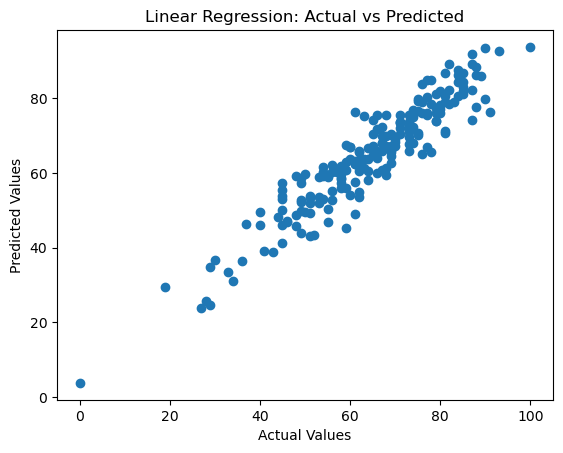

In [43]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

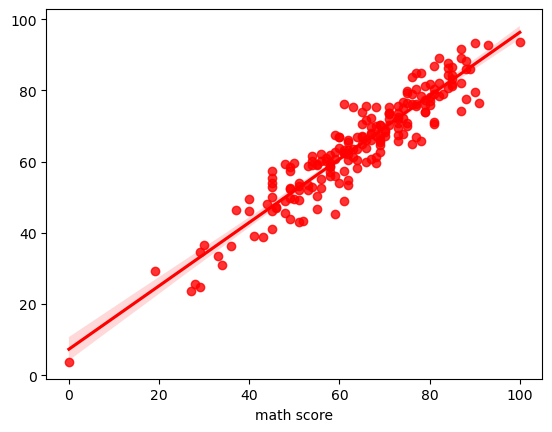

In [47]:
sns.regplot(x=y_test, y=y_pred,ci=95,color='red');

In [48]:
pred_df= pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
pred_df.head()

,Actual,Predicted
521,91,76.387970
737,53,58.885970
740,80,76.990265
660,74,76.851804
411,84,87.627378


## 1.6 Model Training

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 1.7 Prediction

In [ ]:
y_pred = model.predict(X_test)

## 1.8 Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 29.09516986671547
R2 Score: 0.8804332983749565
